In [11]:
# EDA for Mall Customer dataset
# columns: CustomerID, Gender, Age, Annual Income, Spending Score

In [12]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

DATA_PATH = "Data/Mall_Customers.csv"

In [13]:
# load data
df = pd.read_csv(DATA_PATH)
df.columns = ["CustomerID", "Gender", "Age", "Annual_Income", "Spending_Score"]
print("rows:", len(df))
df.head()

rows: 200


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [14]:
# basic info
print(df.dtypes)
df.describe()

CustomerID         int64
Gender            object
Age                int64
Annual_Income      int64
Spending_Score     int64
dtype: object


,CustomerID,Age,Annual_Income,Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [15]:
# missing values check
print(df.isnull().sum())
print("duplicates:", df.duplicated().sum())

CustomerID        0
Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64
duplicates: 0


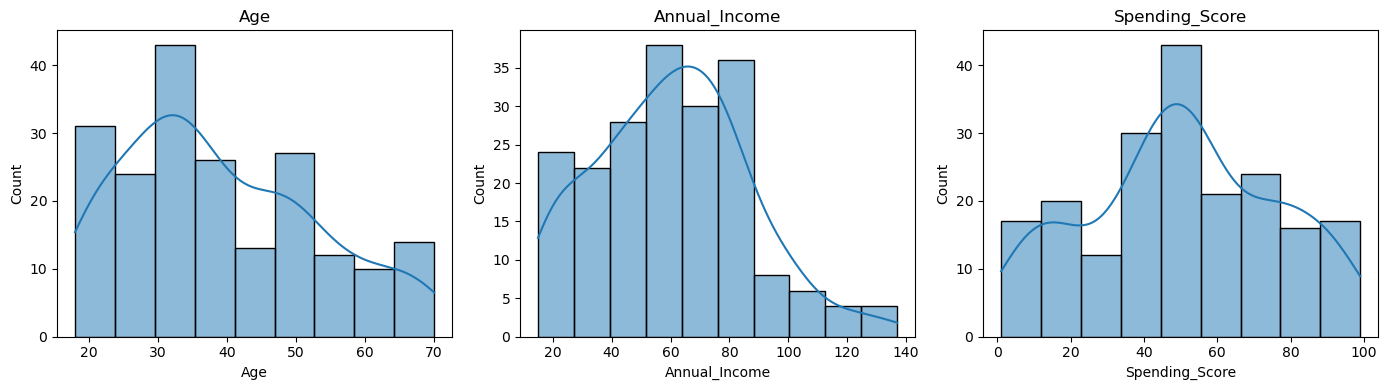

In [16]:
# numerical feature plots
num_cols = ["Age", "Annual_Income", "Spending_Score"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

Gender
Female    112
Male       88
Name: count, dtype: int64


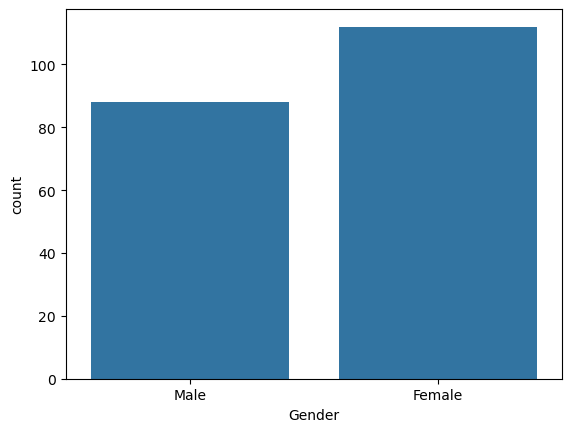

In [17]:
# gender count
print(df["Gender"].value_counts())
sns.countplot(data=df, x="Gender")
plt.show()

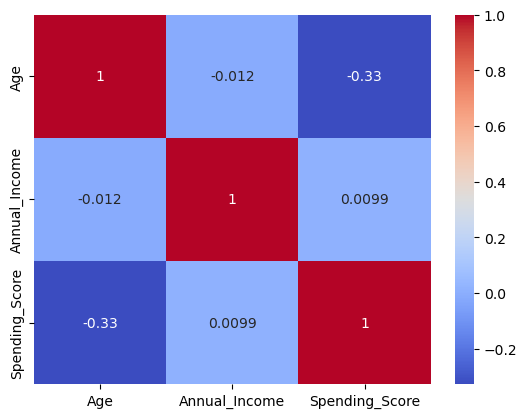

In [18]:
# correlation heatmap
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

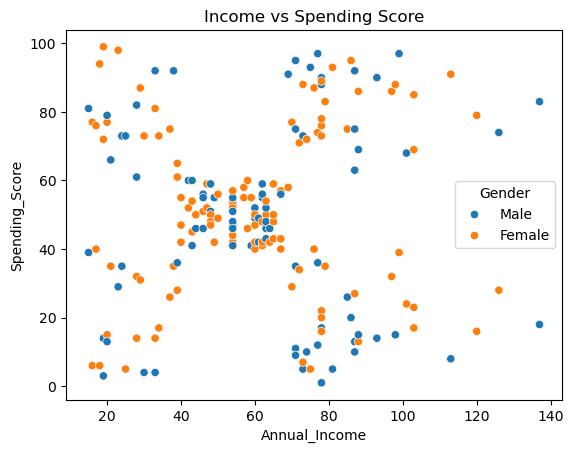

In [19]:
# income vs spending - useful for clustering
sns.scatterplot(data=df, x="Annual_Income", y="Spending_Score", hue="Gender")
plt.title("Income vs Spending Score")
plt.show()

In [20]:
# save cleaned data without customer id
clean_df = df.drop(columns=["CustomerID"])
clean_df.to_csv("Data/Mall_Customers_cleaned.csv", index=False)
print("cleaned file saved")

cleaned file saved
